# Ablation study — Guided RL for Omnidirectional 3D Jumping (Section 5.6)

Three headline figures, one per claim, each showing the effect **relative to the baseline**:

| Figure | Section | Claim |
|---|---|---|
| **A** `fig_landing_degradation` | §6 | landing accuracy degrades relative to the baseline, and *where* in the workspace |
| **B** `fig_bounce_increase` | §7 | the bounce distance grows relative to the baseline, producing landing conditions that must be avoided |
| **C** `fig_liftoff_predictability` | §8 | without the lift-off penalty the achieved lift-off state departs from the commanded one, so the ballistic/physical interpretation of Section 5.2 can no longer be used |

Plus §9 for the UARM feasible-region claim and §10 for the supporting material.

**Why nothing is paired sample-by-sample.** Targets are sampled randomly and independently in each
run, so sample *i* of one run is a different command from sample *i* of another. Every comparison
here is made over a shared grid partition of the command space: policies are compared cell by cell,
aggregates are stratified over cells (each region weighted equally), and confidence intervals come
from a cluster bootstrap over cells. Significance is Wilcoxon signed-rank over cells with Holm
correction, so n is the number of regions rather than the number of jumps.

## 1. Setup

In [29]:
import os
import os.path as osp
import warnings
from itertools import product

import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 500, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.30, "axes.axisbelow": True,
    "legend.frameon": False,
})

G = 9.81      # [m/s^2] gravity, for the ballistic model of Section 5.2

In [30]:
robot = "go1"

cwd = os.getcwd()
data_path = osp.abspath(osp.join(cwd, f"../../../../logs/rsl_rl/unitree_{robot}_jump/ablation"))
# data_path = "/absolute/path/to/ablation"      # <-- override if the relative path is wrong
print("data path :", data_path, "| exists:", osp.isdir(data_path))

FIG_DIR = osp.join(data_path, "figures_ablation")
os.makedirs(FIG_DIR, exist_ok=True)

BASELINE = "baseline"
EXPERIMENTS = {
    "baseline":                    ("Baseline",  "Full reward set"),
    "no_uarm":                     ("w/o UARM",  "No UARM extension of the Bezier thrust"),
    "no_liftoof_disc_penalty":     ("w/o LO",    "No lift-off state penalty"),
    "no_bounce_angular_touchdown": ("w/o TD",    "No touchdown bounce / ang.-vel. penalty"),
}
COLORS = {
    "baseline":                    "#2c3e50",
    "no_uarm":                     "#c0392b",
    "no_liftoof_disc_penalty":     "#2980b9",
    "no_bounce_angular_touchdown": "#e67e22",
}
ABLATIONS = [k for k in EXPERIMENTS if k != BASELINE]

ERR_ACCEPT = 0.20     # [m] paper acceptability threshold (Fig. 10)
ERR_TIGHT  = 0.10     # [m]
PEN_CAP    = 0.50     # [m] censoring cap for the selection-free error metric
START_Z    = 0.0      # subtract from logged z if targets are in world coords (e.g. 0.5)
SAVE_FIGS  = True


def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ("pdf", "png"):
            fig.savefig(osp.join(FIG_DIR, f"{name}.{ext}"), bbox_inches="tight")

data path : /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation | exists: True


## 2. Loading

Three details that change conclusions:

**Three landing-error metrics.** `pos_err` over successful jumps only is *selection biased* — a
policy that fails on the hard targets looks accurate on the ones that survive. `pos_err_pen`
censors failures at `PEN_CAP` and is the headline number. `pos_err_all` is the raw measured error.

**Bounce sentinel.** Section 4.3 sets the bounce cost to a high default when no valid touchdown is
detected. If that value is in `bounce_err.bin` it is a failure flag, not a distance, and it will
inflate the bounce statistics. The loader detects it and counts those samples as invalid touchdowns.

**Full lift-off states.** If `lo_pos_err.bin` / `lo_vel_err.bin` store a `[desired, actual]` pair
(like `pos_err.bin`), §8 runs the exact ballistic analysis. If they store pre-differenced errors it
falls back to a first-order bound and says so.

In [31]:
def _np(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def _load(path):
    if not osp.isfile(path):
        return None
    o = joblib.load(path)
    return [_np(a) for a in o] if isinstance(o, (list, tuple)) else _np(o)


def _is_pair(raw):
    return (isinstance(raw, (list, tuple)) and len(raw) == 2
            and np.shape(raw[0]) == np.shape(raw[1]) and np.ndim(raw[0]) == 2)


def _as_error(raw):
    if raw is None:
        return None
    if _is_pair(raw):
        return np.asarray(raw[1], float) - np.asarray(raw[0], float)
    return np.asarray(raw, float)


def _mag(err, deg=False):
    if err is None:
        return None
    e = np.asarray(err, float)
    if e.ndim == 0:
        return None
    m = np.abs(e) if e.ndim == 1 else np.linalg.norm(e.reshape(len(e), -1), axis=1)
    return np.degrees(m) if deg else m


def detect_sentinel(v, frac=0.01):
    # a single value repeated in more than `frac` of samples and sitting in the upper tail
    if v is None or len(v) == 0:
        return None
    vals, counts = np.unique(np.round(np.asarray(v, float), 6), return_counts=True)
    hi = np.percentile(v, 75)
    cand = [(c, x) for x, c in zip(vals, counts) if c > frac * len(v) and x >= hi]
    return max(cand)[1] if cand else None


def styled_boxplot(ax, data, labels, colors, **kw):
    kwargs = dict(showfliers=False, patch_artist=True,
                  medianprops=dict(color="black", lw=1.4))
    kwargs.update(kw)
    try:
        bp = ax.boxplot(data, tick_labels=labels, **kwargs)
    except TypeError:
        bp = ax.boxplot(data, labels=labels, **kwargs)
    for p, c in zip(bp["boxes"], colors):
        p.set_facecolor(c)
        p.set_alpha(0.55)
    return bp


def ecdf(ax, v, w=None, **kw):
    v = np.asarray(v, float)
    keep = np.isfinite(v)
    v = v[keep]
    o = np.argsort(v)
    v = v[o]
    w = np.ones_like(v) if w is None else np.asarray(w, float)[keep][o]
    ax.step(v, np.cumsum(w) / w.sum(), where="post", **kw)


def as_markdown(df, floatfmt=".3f"):
    try:
        return df.to_markdown(index=False, floatfmt=floatfmt)
    except ImportError:
        return df.to_string(index=False)

In [32]:
class DataExp:
    FILES = {
        "pos":        "pos_err.bin",
        "orient_err": "orient_err.bin",
        "fail":       "failed.bin",
        "bounce":     "bounce_err.bin",
        "lo_pos":     "lo_pos_err.bin",
        "lo_orient":  "lo_orient_err.bin",
        "lo_vel":     "lo_vel_err.bin",
        "lo_ang_vel": "lo_ang_vel_err.bin",
        "td_ang_vel": "td_ang_vel.bin",      # optional
    }

    def __init__(self, data_path, name):
        self.name = name
        self.exp_path = osp.join(data_path, name)
        self.label, self.long_label = EXPERIMENTS.get(name, (name, name))
        self.color = COLORS.get(name, "#555")

    def load(self):
        self.raw = {k: _load(osp.join(self.exp_path, f)) for k, f in self.FILES.items()}
        return self

    def shapes(self):
        rows = []
        for k, v in self.raw.items():
            if v is None:
                rows.append((self.name, k, "-", "MISSING"))
            elif isinstance(v, list):
                rows.append((self.name, k, f"pair[{len(v)}]",
                             " | ".join(str(np.shape(a)) for a in v)))
            else:
                rows.append((self.name, k, str(v.dtype), str(v.shape)))
        return pd.DataFrame(rows, columns=["exp", "field", "kind", "shape"])

    def process(self):
        des = np.asarray(self.raw["pos"][0], float)
        act = np.asarray(self.raw["pos"][1], float)
        self.n = len(des)

        self.des_pos    = des[:, :2]
        self.actual_pos = act[:, :2]
        self.des_z_abs  = des[:, 2] if des.shape[1] > 2 else np.full(self.n, np.nan)
        self.des_z      = self.des_z_abs - START_Z
        self.land_z_abs = act[:, 2] if act.shape[1] > 2 else None

        self.pos_err = np.linalg.norm(self.des_pos - self.actual_pos, axis=1)

        f = self.raw["fail"]
        self.fail = np.zeros(self.n, bool) if f is None else np.asarray(f).reshape(-1).astype(bool)
        self.ok = ~self.fail

        self.pos_err_all = self.pos_err.copy()
        self.pos_err_pen = np.where(self.fail, PEN_CAP, np.minimum(self.pos_err, PEN_CAP))
        self.accept       = self.ok & (self.pos_err <= ERR_ACCEPT)
        self.accept_tight = self.ok & (self.pos_err <= ERR_TIGHT)

        oe = _as_error(self.raw["orient_err"])
        self.yaw_err = (np.degrees(np.abs(oe[:, 2]))
                        if (oe is not None and oe.ndim == 2 and oe.shape[1] >= 3)
                        else _mag(oe, deg=True))

        self.bounce = _mag(_as_error(self.raw["bounce"]))
        self.bounce_sentinel = detect_sentinel(self.bounce) if self.bounce is not None else None
        if self.bounce is None:
            self.bounce_valid = np.ones(self.n, bool)
        elif self.bounce_sentinel is not None:
            self.bounce_valid = ~np.isclose(self.bounce, self.bounce_sentinel)
        else:
            self.bounce_valid = np.ones(self.n, bool)
        self.invalid_td = ~self.bounce_valid

        self.lo_state = {}
        for key in ("lo_pos", "lo_vel", "lo_orient", "lo_ang_vel"):
            if _is_pair(self.raw[key]):
                self.lo_state[key] = (np.asarray(self.raw[key][0], float),
                                      np.asarray(self.raw[key][1], float))
        self.has_lo_state = ("lo_pos" in self.lo_state) and ("lo_vel" in self.lo_state)

        self.lo_pos     = _mag(_as_error(self.raw["lo_pos"]))
        self.lo_orient  = _mag(_as_error(self.raw["lo_orient"]), deg=True)
        self.lo_vel     = _mag(_as_error(self.raw["lo_vel"]))
        self.lo_ang_vel = _mag(_as_error(self.raw["lo_ang_vel"]))
        self.td_ang_vel = _mag(_as_error(self.raw["td_ang_vel"]))

        self.des_dist    = np.linalg.norm(self.des_pos, axis=1)
        self.actual_dist = np.linalg.norm(self.actual_pos, axis=1)
        self.des_angle   = np.arctan2(self.des_pos[:, 1], self.des_pos[:, 0])
        self.is_front    = self.des_pos[:, 0] >= 0
        return self


# attr -> (pretty name, unit, restrict to successful jumps?)
METRICS = {
    "pos_err_pen":  ("Landing error (censored)",  "m",     False),
    "pos_err":      ("Landing error | success",   "m",     True),
    "pos_err_all":  ("Landing error (all jumps)", "m",     False),
    "fail":         ("Failure rate",              "%",     False),
    "invalid_td":   ("Invalid touchdown rate",    "%",     False),
    "accept":       (f"Acceptable @ {ERR_ACCEPT} m", "%",  False),
    "accept_tight": (f"Acceptable @ {ERR_TIGHT} m",  "%",  False),
    "yaw_err":      ("Yaw error",                 "deg",   True),
    "bounce":       ("Bounce distance",           "m",     True),
    "lo_pos":       ("Lift-off position error",   "m",     True),
    "lo_orient":    ("Lift-off orientation error", "deg",  True),
    "lo_vel":       ("Lift-off lin. velocity error", "m/s", True),
    "lo_ang_vel":   ("Lift-off ang. velocity error", "rad/s", True),
    "td_ang_vel":   ("Touchdown angular velocity", "rad/s", True),
}
PCT = {"fail", "invalid_td", "accept", "accept_tight"}
MNAME = {k: v[0] for k, v in METRICS.items()}
MUNIT = {k: v[1] for k, v in METRICS.items()}


def mlabel(k):
    return f"{MNAME.get(k, k)} [{MUNIT.get(k, '-')}]"

In [33]:
exps = {}
for name in EXPERIMENTS:
    e = DataExp(data_path, name)
    if not osp.isdir(e.exp_path):
        print(f"[skip] not found: {e.exp_path}")
        continue
    exps[name] = e.load().process()

base = exps[BASELINE]
abl_present = [n for n in ABLATIONS if n in exps]
LABELS = [e.label for e in exps.values()]
CLR = [e.color for e in exps.values()]

print("loaded :", {e.label: e.n for e in exps.values()})
for n, e in exps.items():
    if e.bounce_sentinel is not None:
        k = int(e.invalid_td.sum())
        print(f"[{e.label}] bounce sentinel {e.bounce_sentinel:.4f} in {k} samples "
              f"({100*k/e.n:.1f}%) -> counted as invalid touchdowns, excluded from bounce stats")
print("full lift-off states:", {e.label: e.has_lo_state for e in exps.values()})

pd.concat([e.shapes() for e in exps.values()], ignore_index=True) \
  .pivot(index="field", columns="exp", values="shape")

loaded : {'Baseline': 4096, 'w/o UARM': 4096, 'w/o LO': 4096, 'w/o TD': 4096}
full lift-off states: {'Baseline': False, 'w/o UARM': False, 'w/o LO': False, 'w/o TD': False}


exp,baseline,no_bounce_angular_touchdown,no_liftoof_disc_penalty,no_uarm
field,,,,
bounce,"(4096,)","(4096,)","(4096,)","(4096,)"
fail,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_ang_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_orient,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_pos,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
orient_err,"(4096, 3)","(4096, 3)","(4096, 3)","(4096, 3)"
pos,"(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)"
td_ang_vel,MISSING,MISSING,MISSING,MISSING


## 3. Shared partition of the command space

In [34]:
GRID_NX, GRID_NY = 15, 10      # ~50-150 samples per run per cell is the sweet spot
MIN_PER_CELL = 5


class Grid:
    def __init__(self, xy, nx, ny):
        self.xe = np.linspace(xy[:, 0].min(), xy[:, 0].max() + 1e-9, nx + 1)
        self.ye = np.linspace(xy[:, 1].min(), xy[:, 1].max() + 1e-9, ny + 1)
        self.nx, self.ny, self.n_cells = nx, ny, nx * ny
        cx = 0.5 * (self.xe[:-1] + self.xe[1:])
        cy = 0.5 * (self.ye[:-1] + self.ye[1:])
        self.centroids = np.array([[cx[i], cy[j]] for i, j in product(range(nx), range(ny))])
        self.cell_area = (self.xe[1] - self.xe[0]) * (self.ye[1] - self.ye[0])

    def assign(self, xy):
        ix = np.clip(np.digitize(xy[:, 0], self.xe) - 1, 0, self.nx - 1)
        iy = np.clip(np.digitize(xy[:, 1], self.ye) - 1, 0, self.ny - 1)
        return (ix * self.ny + iy).astype(int)

    def grid_of(self, values):
        g = np.full((self.nx, self.ny), np.nan)
        for c in range(self.n_cells):
            g[c // self.ny, c % self.ny] = values[c]
        return g

    def plot(self, ax, values, **kw):
        return ax.pcolormesh(self.xe, self.ye, self.grid_of(values).T, shading="flat", **kw)


part = Grid(np.vstack([e.des_pos for e in exps.values()]), GRID_NX, GRID_NY)
for e in exps.values():
    e.cell = part.assign(e.des_pos)

counts = pd.DataFrame({e.label: np.bincount(e.cell, minlength=part.n_cells) for e in exps.values()})
VALID = (counts >= MIN_PER_CELL).all(axis=1).values
valid_cells = np.nonzero(VALID)[0]
cdist = np.linalg.norm(part.centroids, axis=1)
cang = np.arctan2(part.centroids[:, 1], part.centroids[:, 0])
TOTAL_AREA = VALID.sum() * part.cell_area

XLIM = (part.xe[0] - 0.03, part.xe[-1] + 0.03)
YLIM = (part.ye[0] - 0.03, part.ye[-1] + 0.03)

print(f"grid {GRID_NX}x{GRID_NY} = {part.n_cells} cells of {part.cell_area:.4f} m^2")
print(f"usable cells {VALID.sum()}/{part.n_cells} | evaluated area {TOTAL_AREA:.3f} m^2")
print(f"samples per cell: min {counts.values.min()}, median {int(np.median(counts.values))}, "
      f"max {counts.values.max()}")

grid 15x10 = 150 cells of 0.0144 m^2
usable cells 150/150 | evaluated area 2.160 m^2
samples per cell: min 13, median 27, max 43


## 4. Cell statistics, stratified aggregates and paired tests

In [35]:
def cell_values(e, attr):
    v = getattr(e, attr, None)
    if v is None:
        return np.full(part.n_cells, np.nan)
    v = np.asarray(v, float)
    restrict = METRICS.get(attr, (None, None, False))[2]
    extra = e.bounce_valid if attr == "bounce" else np.ones(e.n, bool)
    out = np.full(part.n_cells, np.nan)
    for c in range(part.n_cells):
        m = (e.cell == c) & extra
        if restrict:
            m = m & e.ok
        if m.sum() >= 3:
            out[c] = np.nanmean(v[m])
    return 100.0 * out if attr in PCT else out


def rebuild_cells(attrs=None):
    for a in (attrs or list(METRICS)):
        CELL[a] = pd.DataFrame({n: cell_values(e, a) for n, e in exps.items()})


CELL = {}
rebuild_cells()


def strat(attr, policy):
    return float(np.nanmean(CELL[attr].loc[valid_cells, policy]))


def naive(attr, e):
    v = getattr(e, attr, None)
    if v is None:
        return np.nan
    v = np.asarray(v, float)
    if METRICS.get(attr, (None, None, False))[2]:
        v = v[e.ok]
    return float(100 * np.nanmean(v) if attr in PCT else np.nanmean(v))


def cluster_ci(d, n_boot=5000, alpha=0.05, seed=0):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    if len(d) < 3:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    s = np.nanmean(d[rng.integers(0, len(d), (n_boot, len(d)))], axis=1)
    return float(np.percentile(s, 100 * alpha / 2)), float(np.percentile(s, 100 * (1 - alpha / 2)))


def bar_with_ci(ax, attr, labels=None, colors=None):
    mu, elo, ehi = [], [], []
    for n in exps:
        v = CELL[attr].loc[valid_cells, n].values
        m = np.nanmean(v)
        lo, hi = cluster_ci(v)
        mu.append(m); elo.append(max(m - lo, 0)); ehi.append(max(hi - m, 0))
    ax.bar(labels or LABELS, mu, yerr=[elo, ehi], color=colors or CLR, alpha=0.88, capsize=5)
    ax.tick_params(axis="x", rotation=15, labelsize=9)
    return np.array(mu), np.array(ehi)


def annotate_bars(ax, mu, ehi, fmt="{:.3f}", pad=0.03):
    span = max(np.nanmax(np.asarray(mu) + np.asarray(ehi)), 1e-9)
    for i, (v, h) in enumerate(zip(mu, ehi)):
        ax.text(i, v + h + pad * span, fmt.format(v), ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, (1 + 4 * pad) * span)


def stars(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "n.s."


def holm(p):
    p = np.asarray(p, float)
    o = np.argsort(p)
    m, adj, run = len(p), np.empty(len(p)), 0.0
    for rank, i in enumerate(o):
        run = max(run, (m - rank) * p[i])
        adj[i] = min(run, 1.0)
    return adj


def cell_compare(abl, attr):
    x = CELL[attr].loc[valid_cells, BASELINE].values
    y = CELL[attr].loc[valid_cells, abl].values
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 5:
        return None
    x, y = x[m], y[m]
    d = y - x
    lo, hi = cluster_ci(d)
    try:
        p = stats.wilcoxon(x, y).pvalue if np.any(d != 0) else 1.0
    except ValueError:
        p = 1.0
    return dict(Ablation=exps[abl].label, Metric=mlabel(attr), attr=attr, cells=int(m.sum()),
                baseline=float(x.mean()), ablation=float(y.mean()), diff=float(d.mean()),
                ci_lo=lo, ci_hi=hi,
                rel=float(100 * d.mean() / abs(x.mean())) if x.mean() else np.nan,
                worse=float(100 * np.mean(d > 0)), p=float(p))


def rebuild_stats():
    rows = [r for n in abl_present for a in CELL if (r := cell_compare(n, a)) is not None]
    df = pd.DataFrame(rows)
    df["p_holm"] = holm(df["p"].values)
    df["sig"] = [stars(p) for p in df["p_holm"]]
    return df


stats_df = rebuild_stats()


def S(abl_name, attr, field):
    r = stats_df[(stats_df["Ablation"] == exps[abl_name].label) & (stats_df["attr"] == attr)]
    return np.nan if r.empty else r.iloc[0][field]


summary = pd.DataFrame([{"Policy": e.label, **{mlabel(a): strat(a, n) for a in METRICS}}
                        for n, e in exps.items()])
summary.set_index("Policy").T.round(4)

/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


Policy,Baseline,w/o UARM,w/o LO,w/o TD
Landing error (censored) [m],0.0796,0.0892,0.1017,0.0876
Landing error | success [m],0.0734,0.0773,0.1024,0.0688
Landing error (all jumps) [m],0.0740,0.0781,0.1024,0.0702
Failure rate [%],1.5343,3.0294,0.0000,4.4111
Invalid touchdown rate [%],0.0000,0.0000,0.0000,0.0000
Acceptable @ 0.2 m [%],85.6749,84.4802,80.7469,84.1185
Acceptable @ 0.1 m [%],76.2817,74.4326,69.4236,75.6241
Yaw error [deg],3.7175,2.8169,2.9221,4.5022
Bounce distance [m],0.1579,0.1598,0.1422,0.1689
Lift-off position error [m],0.0209,0.0170,0.0262,0.0214


In [36]:
# how much did the random target draws differ? this is the confound the stratification removes
comp = pd.DataFrame({
    "naive pooled": {e.label: naive("pos_err_pen", e) for e in exps.values()},
    "stratified":   {e.label: strat("pos_err_pen", n) for n, e in exps.items()},
})
comp["difference"] = comp["stratified"] - comp["naive pooled"]
print("Censored landing error [m]")
comp.round(4)

Censored landing error [m]


,naive pooled,stratified,difference
Baseline,0.0790,0.0796,0.0007
w/o UARM,0.0886,0.0892,0.0006
w/o LO,0.0956,0.1017,0.0061
w/o TD,0.0859,0.0876,0.0017


## 5. Difference-map helpers

All three headline figures share the same visual grammar: a row of per-cell difference maps
(ablation − baseline, diverging colour scale centred on zero, red = worse than baseline), then a row
quantifying the same thing as a distribution, a stratified bar with CI, and a trend against
commanded distance.

In [37]:
def shared_norm(attr, pct=97, floor=1e-4):
    d = np.concatenate([(CELL[attr][n].values - CELL[attr][BASELINE].values)[valid_cells]
                        for n in abl_present])
    lim = np.nanpercentile(np.abs(d), pct)
    lim = floor if (not np.isfinite(lim) or lim <= 0) else lim
    return TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)


def delta_map(ax, attr, abl, norm, cmap="coolwarm", title=True):
    d = CELL[attr][abl].values - CELL[attr][BASELINE].values
    d = np.where(VALID, d, np.nan)
    m = part.plot(ax, d, cmap=cmap, norm=norm)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
    if title:
        worse = 100 * np.nanmean(d[valid_cells] > 0)
        ax.set_title(f"{exps[abl].label} $-$ Baseline\n"
                     f"$\\Delta$ {np.nanmean(d[valid_cells]):+.3f} {MUNIT[attr]} | "
                     f"worse in {worse:.0f}% of workspace", fontsize=9.5)
    return m


R_EDGES = np.quantile(cdist[valid_cells], np.linspace(0, 1, 7))
R_C = 0.5 * (R_EDGES[:-1] + R_EDGES[1:])


def radial_profile(attr, policy, delta=False):
    v = CELL[attr][policy].values
    if delta:
        v = v - CELL[attr][BASELINE].values
    out, lo, hi = [], [], []
    for a, b in zip(R_EDGES[:-1], R_EDGES[1:]):
        sel = valid_cells[(cdist[valid_cells] >= a) & (cdist[valid_cells] <= b)]
        out.append(np.nanmean(v[sel]))
        l, h = cluster_ci(v[sel], n_boot=2000)
        lo.append(l); hi.append(h)
    return np.array(out), np.array(lo), np.array(hi)


def plot_radial(ax, attr, delta=False, band=True, only=None):
    for n, e in exps.items():
        if delta and n == BASELINE:
            continue
        if only and n not in only:
            continue
        y, lo, hi = radial_profile(attr, n, delta=delta)
        ax.plot(R_C, y, "-o", ms=4, lw=2, color=e.color,
                label=f"{e.label} $-$ Baseline" if delta else e.label)
        if band:
            ax.fill_between(R_C, lo, hi, color=e.color, alpha=0.15, lw=0)
    if delta:
        ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("Commanded distance [m]")
    ax.legend(fontsize=8)

## 6. Figure A — landing degradation relative to the baseline

Top row: per-cell landing-error difference. Red means the ablation lands further from the commanded
target than the baseline does in that region of the workspace. Bottom row: the same effect as a
distribution over cells, as a stratified mean with cluster-bootstrap CI, and as a function of
commanded jump distance.

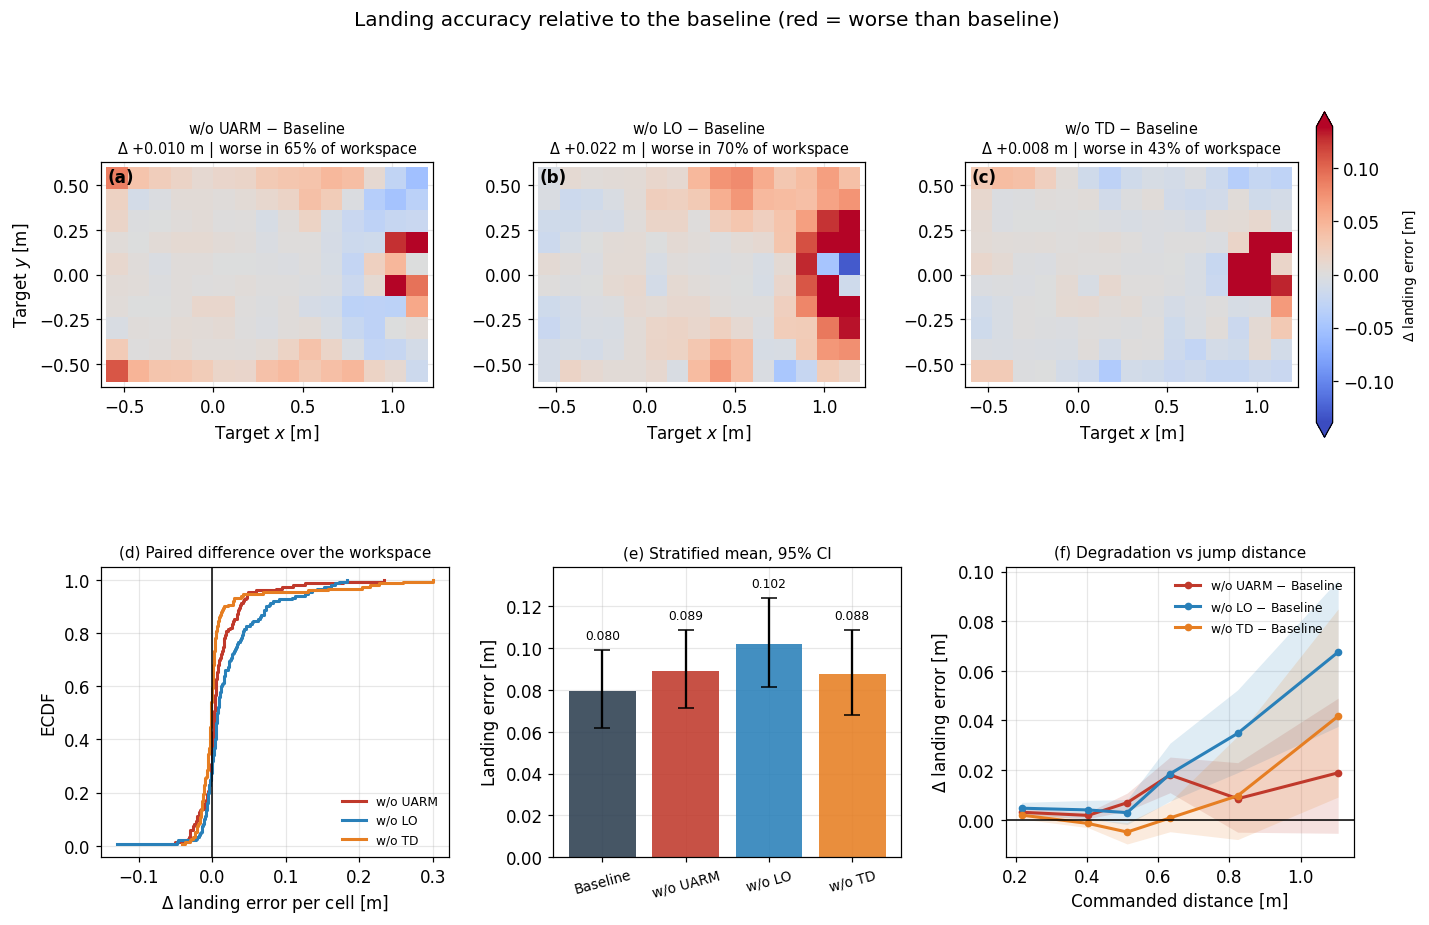

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
0,w/o UARM,0.0796,0.0892,0.0095,0.0044,0.0153,11.9432,65.3333,0.0045,**
13,w/o LO,0.0796,0.1017,0.0221,0.0151,0.0294,27.6969,70.0000,0.0000,***
26,w/o TD,0.0796,0.0876,0.0079,0.0008,0.0166,9.9535,42.6667,0.8048,n.s.


In [38]:
attr = "pos_err_pen"
nA = len(abl_present)
ncol = max(nA, 3)
fig = plt.figure(figsize=(4.9 * ncol, 8.8))
gs = fig.add_gridspec(2, ncol, height_ratios=[1.12, 1.0], hspace=0.42, wspace=0.30)
norm = shared_norm(attr)

top_axes = []
for i, n in enumerate(abl_present):
    ax = fig.add_subplot(gs[0, i])
    top_axes.append(ax)
    m = delta_map(ax, attr, n, norm)
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
    ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes, va="top", fontsize=11,
            fontweight="bold")
cb = fig.colorbar(m, ax=top_axes, pad=0.015, extend="both", fraction=0.03)
cb.set_label("$\\Delta$ landing error [m]", fontsize=9)

ax = fig.add_subplot(gs[1, 0])
for n in abl_present:
    d = (CELL[attr][n].values - CELL[attr][BASELINE].values)[valid_cells]
    ecdf(ax, d, color=exps[n].color, lw=2, label=exps[n].label)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("$\\Delta$ landing error per cell [m]")
ax.set_ylabel("ECDF")
ax.set_title(f"({chr(97+nA)}) Paired difference over the workspace", fontsize=10)
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 1])
mu, ehi = bar_with_ci(ax, attr)
annotate_bars(ax, mu, ehi)
ax.set_ylabel("Landing error [m]")
ax.set_title(f"({chr(98+nA)}) Stratified mean, 95% CI", fontsize=10)

ax = fig.add_subplot(gs[1, 2])
plot_radial(ax, attr, delta=True)
ax.set_ylabel("$\\Delta$ landing error [m]")
ax.set_title(f"({chr(99+nA)}) Degradation vs jump distance", fontsize=10)

fig.suptitle("Landing accuracy relative to the baseline (red = worse than baseline)", y=0.985)
savefig(fig, "fig_landing_degradation")
plt.show()

cols = ["Ablation", "baseline", "ablation", "diff", "ci_lo", "ci_hi", "rel", "worse",
        "p_holm", "sig"]
stats_df[stats_df["attr"] == attr][cols].round(4)

## 7. Figure B — bounce distance relative to the baseline

Same grammar. Note that samples carrying the invalid-touchdown sentinel are excluded from the bounce
statistics and reported separately in panel (f) — an invalid touchdown is a worse outcome than a
large bounce, not a larger one, so mixing them would understate the effect in one place and
overstate it in another.

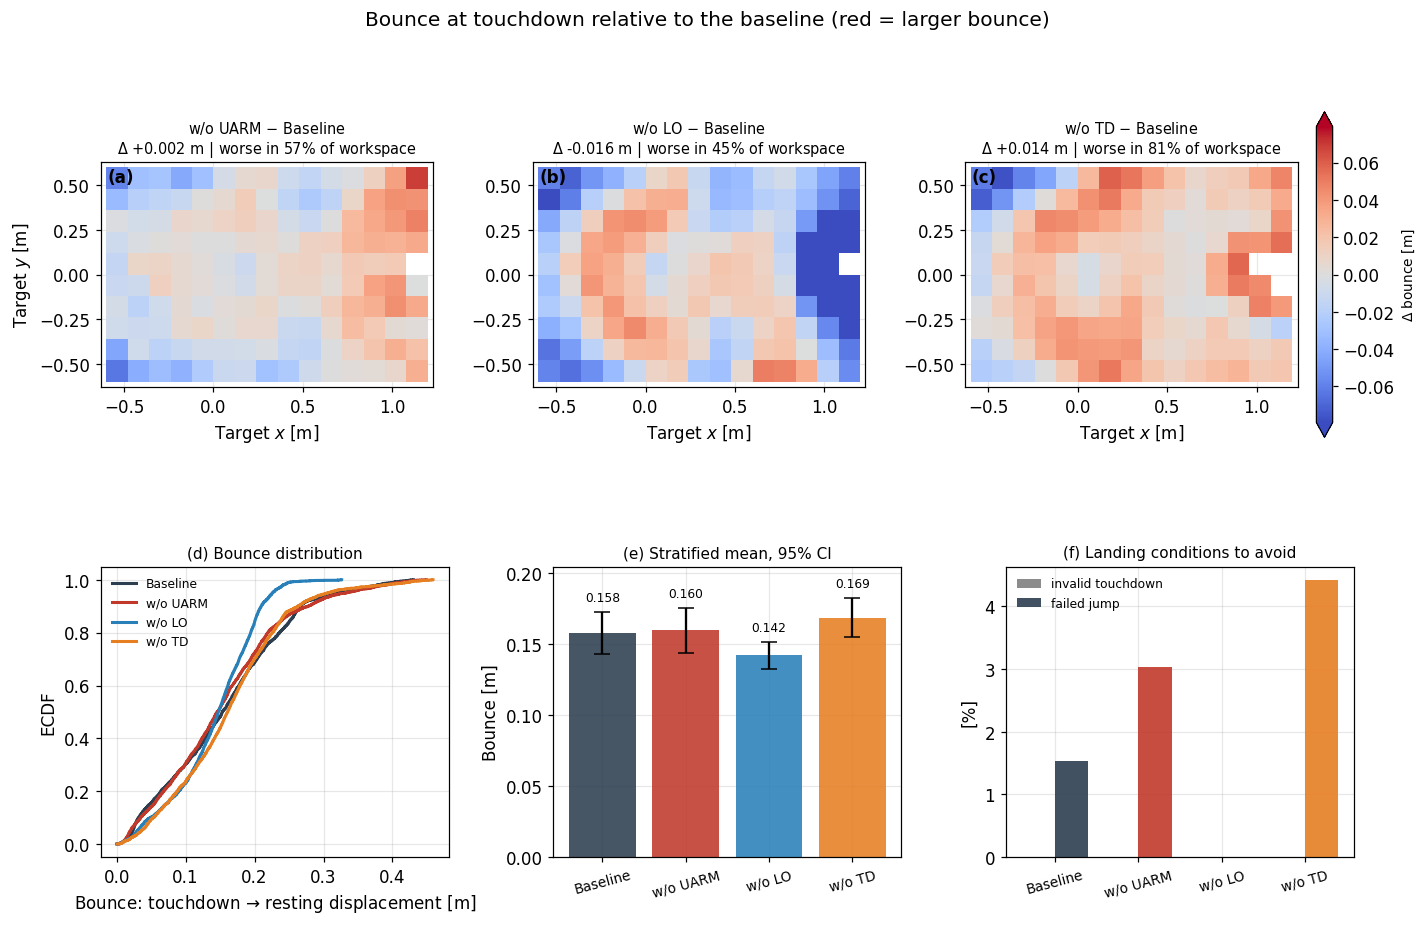

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
4,w/o UARM,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,1.0000,n.s.
8,w/o UARM,0.1579,0.1598,0.0019,-0.0014,0.0054,1.2349,57.0470,1.0000,n.s.
17,w/o LO,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,1.0000,n.s.
21,w/o LO,0.1579,0.1415,-0.0164,-0.0241,-0.0091,-10.3590,44.9664,0.0375,*
30,w/o TD,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,1.0000,n.s.
34,w/o TD,0.1546,0.1689,0.0143,0.0103,0.0180,9.2677,82.9932,0.0000,***


In [39]:
if base.bounce is None:
    print("bounce_err.bin not found — skipping Figure B")
else:
    attr = "bounce"
    fig = plt.figure(figsize=(4.9 * ncol, 8.8))
    gs = fig.add_gridspec(2, ncol, height_ratios=[1.12, 1.0], hspace=0.42, wspace=0.30)
    norm = shared_norm(attr)

    top_axes = []
    for i, n in enumerate(abl_present):
        ax = fig.add_subplot(gs[0, i])
        top_axes.append(ax)
        m = delta_map(ax, attr, n, norm)
        if i == 0:
            ax.set_ylabel("Target $y$ [m]")
        ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes, va="top", fontsize=11,
                fontweight="bold")
    cb = fig.colorbar(m, ax=top_axes, pad=0.015, extend="both", fraction=0.03)
    cb.set_label("$\\Delta$ bounce [m]", fontsize=9)

    ax = fig.add_subplot(gs[1, 0])
    for n, e in exps.items():
        ecdf(ax, e.bounce[e.bounce_valid & e.ok], color=e.color, lw=2, label=e.label)
    ax.set_xlabel("Bounce: touchdown $\\to$ resting displacement [m]")
    ax.set_ylabel("ECDF")
    ax.set_title(f"({chr(97+nA)}) Bounce distribution", fontsize=10)
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    mu, ehi = bar_with_ci(ax, attr)
    annotate_bars(ax, mu, ehi)
    ax.set_ylabel("Bounce [m]")
    ax.set_title(f"({chr(98+nA)}) Stratified mean, 95% CI", fontsize=10)

    ax = fig.add_subplot(gs[1, 2])
    xx = np.arange(len(exps))
    inval = [strat("invalid_td", n) for n in exps]
    fails = [strat("fail", n) for n in exps]
    ax.bar(xx - 0.2, inval, width=0.4, color="0.55", label="invalid touchdown")
    ax.bar(xx + 0.2, fails, width=0.4, color=CLR, alpha=0.9, label="failed jump")
    ax.set_xticks(xx); ax.set_xticklabels(LABELS, rotation=15, fontsize=9)
    ax.set_ylabel("[%]")
    ax.set_title(f"({chr(99+nA)}) Landing conditions to avoid", fontsize=10)
    ax.legend(fontsize=8)

    fig.suptitle("Bounce at touchdown relative to the baseline (red = larger bounce)", y=0.985)
    savefig(fig, "fig_bounce_increase")
    plt.show()

    display(stats_df[stats_df["attr"].isin(["bounce", "invalid_td", "td_ang_vel"])][cols].round(4))

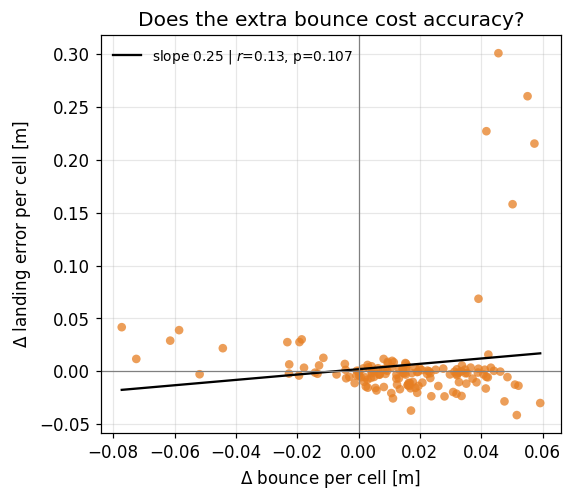

Pearson r = 0.133 (p = 0.1071) | Spearman rho = -0.170 (p = 0.0397)
-> no significant link. Claim the bounce increase and the invalid-touchdown rate,
   NOT that the bounce degrades landing accuracy.


In [40]:
# does the extra bounce translate into worse landings, cell by cell?
tgt = "no_bounce_angular_touchdown"
if tgt in exps and exps[tgt].bounce is not None:
    db = (CELL["bounce"][tgt].values - CELL["bounce"][BASELINE].values)[valid_cells]
    de = (CELL["pos_err_pen"][tgt].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    m = np.isfinite(db) & np.isfinite(de)
    r, rho = stats.pearsonr(db[m], de[m]), stats.spearmanr(db[m], de[m])

    fig, ax = plt.subplots(figsize=(5.4, 4.7))
    ax.scatter(db[m], de[m], s=32, color=exps[tgt].color, alpha=0.75, edgecolors="none")
    sl, ic = np.polyfit(db[m], de[m], 1)
    xs = np.linspace(db[m].min(), db[m].max(), 10)
    ax.plot(xs, sl * xs + ic, "k-", lw=1.5,
            label=f"slope {sl:.2f} | $r$={r.statistic:.2f}, p={r.pvalue:.3f}")
    ax.axhline(0, color="grey", lw=.8); ax.axvline(0, color="grey", lw=.8)
    ax.set_xlabel("$\\Delta$ bounce per cell [m]")
    ax.set_ylabel("$\\Delta$ landing error per cell [m]")
    ax.set_title("Does the extra bounce cost accuracy?")
    ax.legend(fontsize=9)
    savefig(fig, "fig_bounce_mechanism")
    plt.show()
    print(f"Pearson r = {r.statistic:.3f} (p = {r.pvalue:.4f}) | "
          f"Spearman rho = {rho.statistic:.3f} (p = {rho.pvalue:.4f})")
    if r.pvalue > 0.05:
        print("-> no significant link. Claim the bounce increase and the invalid-touchdown rate,")
        print("   NOT that the bounce degrades landing accuracy.")

## 8. Figure C — lift-off state deviation and the loss of the physical interpretation

The argument has two links and the figure shows both.

**Link 1 — the state is off.** Removing the penalty degrades tracking of the commanded lift-off
state: panel (a) for the components, panel (b) for where in the workspace.

**Link 2 — therefore the physics can no longer be used.** Section 5.2 evaluates the apex check (27)
and the landing prediction (1) on the *commanded* lift-off state, before the jump runs. If the robot
does not realise that state, those equations describe a jump that never happens. With full lift-off
states logged, the error is decomposed as

    |predicted from commanded − actual landing|
        ≈ |predicted from commanded − predicted from achieved|   (lift-off tracking)
        + |predicted from achieved  − actual landing|            (ballistic model)

and the claim is that the **first** term is what grows — the flight model is still fine, the state
fed into it is not.

In [41]:
def flight_time(clo_z, vlo_z, z_land):
    disc = vlo_z ** 2 + 2 * G * (clo_z - z_land)
    return np.where(disc >= 0, (vlo_z + np.sqrt(np.clip(disc, 0, None))) / G, np.nan)


def apex_height(clo_z, vlo_z):
    return clo_z + vlo_z ** 2 / (2 * G)              # paper eq. (27)


def predict_landing(clo, vlo, z_land):
    T = flight_time(clo[:, 2], vlo[:, 2], z_land)
    return clo[:, :2] + vlo[:, :2] * T[:, None], T


BALLISTIC = all(e.has_lo_state for e in exps.values())
print("exact ballistic decomposition available:", BALLISTIC)

if BALLISTIC:
    for n, e in exps.items():
        clo_d, clo_a = e.lo_state["lo_pos"]
        vlo_d, vlo_a = e.lo_state["lo_vel"]
        z_land = e.land_z_abs if e.land_z_abs is not None else np.full(e.n, clo_d[:, 2].mean())
        p_cmd, _ = predict_landing(clo_d, vlo_d, z_land)
        p_act, _ = predict_landing(clo_a, vlo_a, z_land)
        e.pred_err_filter = np.linalg.norm(p_cmd - e.actual_pos, axis=1)
        e.pred_err_model  = np.linalg.norm(p_act - e.actual_pos, axis=1)
        e.pred_err_lo     = np.linalg.norm(p_cmd - p_act, axis=1)
        e.apex_err = np.abs(apex_height(clo_d[:, 2], vlo_d[:, 2])
                            - apex_height(clo_a[:, 2], vlo_a[:, 2]))
        e.apex_cmd = apex_height(clo_d[:, 2], vlo_d[:, 2])
else:
    print()
    print("Falling back to a first-order bound |dc_lo| + T|dv_lo|. To get the exact")
    print("decomposition, dump the lift-off states as pairs, the same way pos_err.bin is stored:")
    print("    joblib.dump([clo_des, clo_act], 'lo_pos_err.bin')")
    print("    joblib.dump([vlo_des, vlo_act], 'lo_vel_err.bin')")
    T_FL_NOMINAL = 0.45          # [s] set from your data
    for n, e in exps.items():
        lp = e.lo_pos if e.lo_pos is not None else np.zeros(e.n)
        lv = e.lo_vel if e.lo_vel is not None else np.zeros(e.n)
        e.pred_err_lo = lp + T_FL_NOMINAL * lv
        e.pred_err_filter = np.full(e.n, np.nan)
        e.pred_err_model = np.full(e.n, np.nan)
        e.apex_err = np.full(e.n, np.nan)

for k, nm in (("pred_err_filter", "Landing prediction error (pre-jump)"),
              ("pred_err_lo", "  of which: lift-off tracking"),
              ("pred_err_model", "  of which: ballistic model"),
              ("apex_err", "Apex prediction error")):
    METRICS[k] = (nm, "m", True)
    MNAME[k], MUNIT[k] = nm, "m"
rebuild_cells(["pred_err_filter", "pred_err_lo", "pred_err_model", "apex_err"])
stats_df = rebuild_stats()
print("ok")

exact ballistic decomposition available: False

Falling back to a first-order bound |dc_lo| + T|dv_lo|. To get the exact
decomposition, dump the lift-off states as pairs, the same way pos_err.bin is stored:
    joblib.dump([clo_des, clo_act], 'lo_pos_err.bin')
    joblib.dump([vlo_des, vlo_act], 'lo_vel_err.bin')
ok


/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


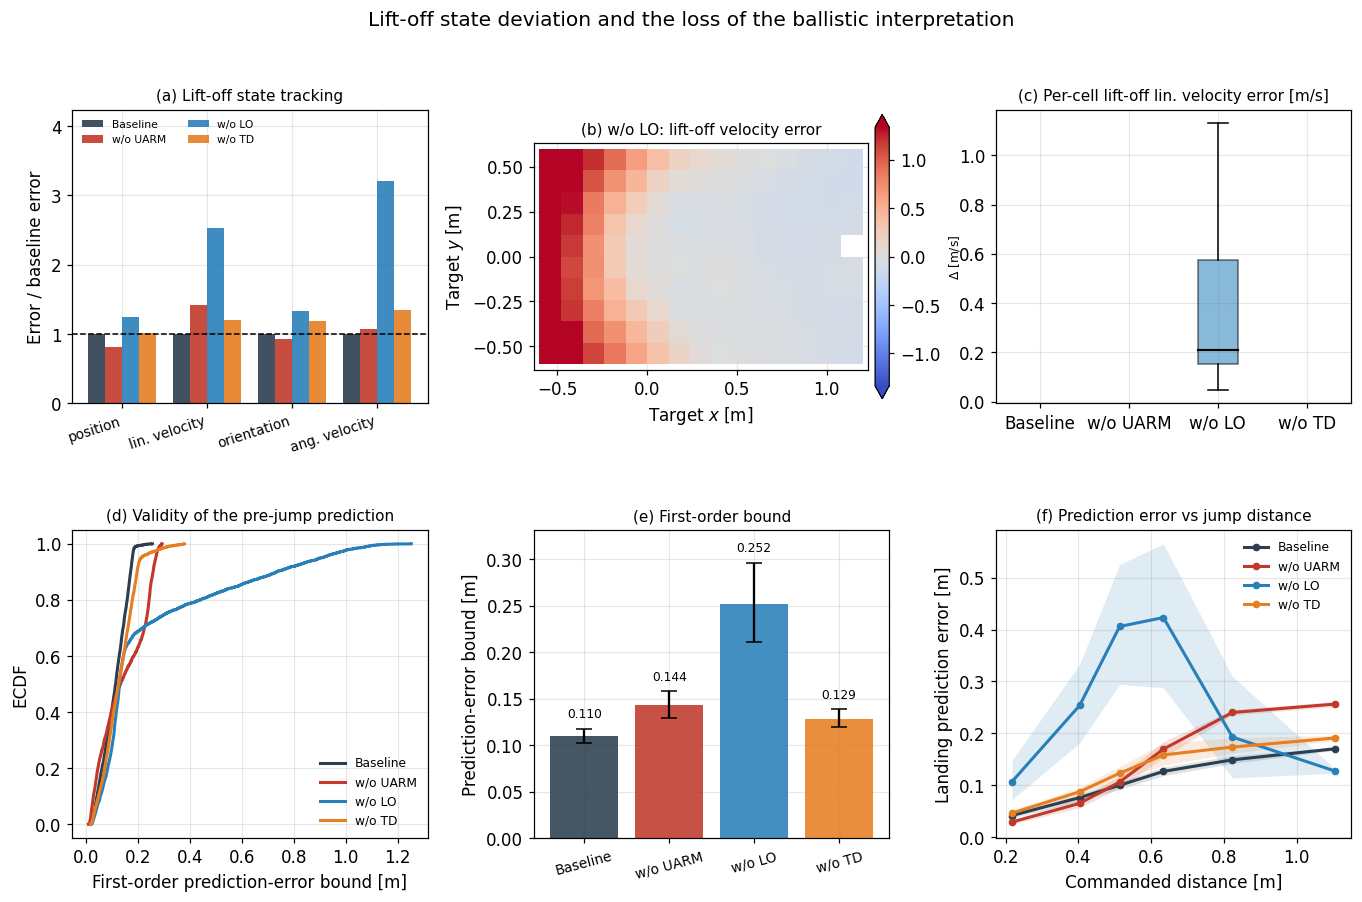

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
9,w/o UARM,0.0209,0.0170,-0.0040,-0.0046,-0.0034,-18.9550,16.1074,0.0000,***
10,w/o UARM,2.2979,2.1423,-0.1555,-0.2545,-0.0622,-6.7689,45.6376,0.4212,n.s.
11,w/o UARM,0.1981,0.2814,0.0833,0.0645,0.1028,42.0326,61.0738,0.0000,***
12,w/o UARM,0.4298,0.4644,0.0346,0.0028,0.0666,8.0509,56.3758,0.8882,n.s.
13,w/o UARM,0.1101,0.1436,0.0335,0.0253,0.0419,30.4333,57.7181,0.0000,***
23,w/o LO,0.0209,0.0261,0.0052,0.0036,0.0069,24.8645,63.0872,0.0000,***
24,w/o LO,2.2979,3.0774,0.7796,0.6269,0.9324,33.9263,75.8389,0.0000,***
25,w/o LO,0.1981,0.5028,0.3047,0.2166,0.3975,153.8109,48.3221,0.0440,*
26,w/o LO,0.4298,1.3815,0.9517,0.8671,1.0374,221.4271,98.6577,0.0000,***
27,w/o LO,0.1101,0.2524,0.1423,0.1014,0.1855,129.2866,50.3356,0.0119,*


In [42]:
LO_ATTRS = [a for a in ("lo_pos", "lo_vel", "lo_orient", "lo_ang_vel")
            if np.isfinite(CELL[a][BASELINE].values[valid_cells]).any()]
KEY = "pred_err_filter" if BALLISTIC else "pred_err_lo"

fig = plt.figure(figsize=(15, 8.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.05], hspace=0.42, wspace=0.30)

# (a) lift-off components, normalised to the baseline
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(LO_ATTRS)); w = 0.8 / max(len(exps), 1)
for i, (n, e) in enumerate(exps.items()):
    vals = [strat(a, n) / max(strat(a, BASELINE), 1e-12) for a in LO_ATTRS]
    ax.bar(x + i * w - 0.4 + w / 2, vals, width=w, color=e.color, alpha=0.9, label=e.label)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([MNAME[a].replace("Lift-off ", "").replace(" error", "")
                    for a in LO_ATTRS], rotation=18, ha="right", fontsize=9)
ax.set_ylabel("Error / baseline error")
ax.set_title("(a) Lift-off state tracking", fontsize=10)
ax.set_ylim(0, 1.32 * max(1.0, max(strat(a, n) / max(strat(a, BASELINE), 1e-12)
                                   for a in LO_ATTRS for n in exps)))
ax.legend(fontsize=7, loc="upper left", ncol=2)

# (b) where the lift-off velocity tracking degrades
ax = fig.add_subplot(gs[0, 1])
lo_key = "lo_vel" if "lo_vel" in LO_ATTRS else LO_ATTRS[0]
tgt = "no_liftoof_disc_penalty" if "no_liftoof_disc_penalty" in exps else abl_present[0]
m = delta_map(ax, lo_key, tgt, shared_norm(lo_key))
ax.set_ylabel("Target $y$ [m]")
cb = fig.colorbar(m, ax=ax, pad=0.02, extend="both", fraction=0.04)
cb.set_label(f"$\\Delta$ [{MUNIT[lo_key]}]", fontsize=8)
ax.set_title(f"(b) {exps[tgt].label}: lift-off velocity error", fontsize=10)

# (c) apex prediction error -- the quantity eq. (27) depends on
ax = fig.add_subplot(gs[0, 2])
if BALLISTIC:
    mu, ehi = bar_with_ci(ax, "apex_err")
    annotate_bars(ax, mu, ehi)
    ax.set_title("(c) Apex prediction error of eq. (27)  [m]", fontsize=10)
else:
    styled_boxplot(ax, [CELL[lo_key].loc[valid_cells, n].values for n in exps], LABELS, CLR)
    ax.set_title(f"(c) Per-cell {MNAME[lo_key].lower()} [{MUNIT[lo_key]}]", fontsize=10)

# (d) the consequence: pre-jump landing prediction is wrong
ax = fig.add_subplot(gs[1, 0])
for n, e in exps.items():
    v = getattr(e, KEY)
    ecdf(ax, v[e.ok], color=e.color, lw=2, label=e.label)
ax.set_xlabel("Predicted $-$ actual landing point [m]" if BALLISTIC
              else "First-order prediction-error bound [m]")
ax.set_ylabel("ECDF")
ax.set_title("(d) Validity of the pre-jump prediction", fontsize=10)
ax.legend(fontsize=8)

# (e) decomposition
ax = fig.add_subplot(gs[1, 1])
if BALLISTIC:
    lo_sh = [strat("pred_err_lo", n) for n in exps]
    md_sh = [strat("pred_err_model", n) for n in exps]
    ax.bar(LABELS, md_sh, color="0.72", label="ballistic model error")
    ax.bar(LABELS, lo_sh, bottom=md_sh, color=CLR, alpha=0.92, label="lift-off tracking")
    for i, (a, b) in enumerate(zip(md_sh, lo_sh)):
        ax.text(i, a + b, f" {a+b:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Landing prediction error [m]")
    ax.set_title("(e) What breaks the prediction", fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=15, labelsize=9)
else:
    mu, ehi = bar_with_ci(ax, "pred_err_lo")
    annotate_bars(ax, mu, ehi)
    ax.set_ylabel("Prediction-error bound [m]")
    ax.set_title("(e) First-order bound", fontsize=10)

# (f) prediction error vs commanded distance
ax = fig.add_subplot(gs[1, 2])
plot_radial(ax, KEY, delta=False)
ax.set_ylabel("Landing prediction error [m]")
ax.set_title("(f) Prediction error vs jump distance", fontsize=10)

fig.suptitle("Lift-off state deviation and the loss of the ballistic interpretation", y=0.985)
savefig(fig, "fig_liftoff_predictability")
plt.show()

display(stats_df[stats_df["attr"].isin(LO_ATTRS + [KEY, "apex_err"])][cols].round(4))

In [43]:
# would the pre-jump feasibility check of eq. (27) still be trustworthy?
if BALLISTIC:
    if np.nanstd(base.des_z_abs) < 1e-6:
        print("NOTE: all targets are at the same height, so the apex GATE of eq. (27) never binds")
        print("      here. The informative quantities are the apex and landing PREDICTION errors")
        print("      above. Re-run on the elevated-target set to exercise the gate itself.")
        print()
    rows = []
    for n, e in exps.items():
        passes = e.apex_cmd >= e.des_z_abs
        rows.append({
            "Policy": e.label,
            "Filter accepts [%]": 100 * np.nanmean(passes),
            "False accept [%]": 100 * (passes & ~e.accept).sum() / max(np.nansum(passes), 1),
            "Apex pred. err [m]": strat("apex_err", n),
            "Landing pred. err [m]": strat("pred_err_filter", n),
            "  lift-off share [m]": strat("pred_err_lo", n),
            "  model share [m]": strat("pred_err_model", n),
        })
    display(pd.DataFrame(rows).set_index("Policy").round(4))
else:
    print("Needs the full lift-off states (see §8 first cell).")

Needs the full lift-off states (see §8 first cell).


## 9. UARM: the feasible region

The feasible region uses the paper's own criterion — landing error below 0.2 m (Fig. 10) — but is
reported as an **area in m²** rather than left to the eye. The area is computed as the stratified
acceptance rate times the evaluated command-space area, which does not saturate the way a
whole-cell vote does. The threshold sweep in panel (c) removes any suspicion that 0.2 m was
chosen to flatter the result.

In [44]:
def effective_area(n, thr=ERR_ACCEPT):
    e = exps[n]
    good = e.ok & (e.pos_err <= thr)
    acc = np.full(part.n_cells, np.nan)
    for c in valid_cells:
        m = e.cell == c
        if m.sum() >= 3:
            acc[c] = good[m].mean()
    return float(np.nanmean(acc[valid_cells])) * TOTAL_AREA


def usable_range(n, thr=ERR_ACCEPT, frac=0.5, nb=14):
    e = exps[n]
    good = e.ok & (e.pos_err <= thr)
    edges = np.linspace(0, e.des_dist.max(), nb + 1)
    last = 0.0
    for a, b in zip(edges[:-1], edges[1:]):
        m = (e.des_dist >= a) & (e.des_dist < b)
        if m.sum() >= 10 and good[m].mean() >= frac:
            last = b
    return last


feas_area = {n: effective_area(n) for n in exps}
feas_mask = {n: (CELL["accept"][n].values >= 50.0) & VALID for n in exps}

feas_df = pd.DataFrame([{
    "Policy": e.label,
    "Feasible area [m2]": feas_area[n],
    "vs baseline [%]": 100 * (feas_area[n] - feas_area[BASELINE]) / feas_area[BASELINE],
    "Usable range [m]": usable_range(n),
    "Landing err [m]": strat("pos_err_pen", n),
    "Failure rate [%]": strat("fail", n),
} for n, e in exps.items()]).set_index("Policy")
feas_df.round(4)

,Feasible area [m2],vs baseline [%],Usable range [m],Landing err [m],Failure rate [%]
Policy,,,,,
Baseline,1.8502,0.0000,0.9503,0.0796,1.5343
w/o UARM,1.8244,-1.3945,0.9518,0.0892,3.0294
w/o LO,1.7438,-5.7520,0.9359,0.1017,0.0000
w/o TD,1.8166,-1.8167,0.9529,0.0876,4.4111


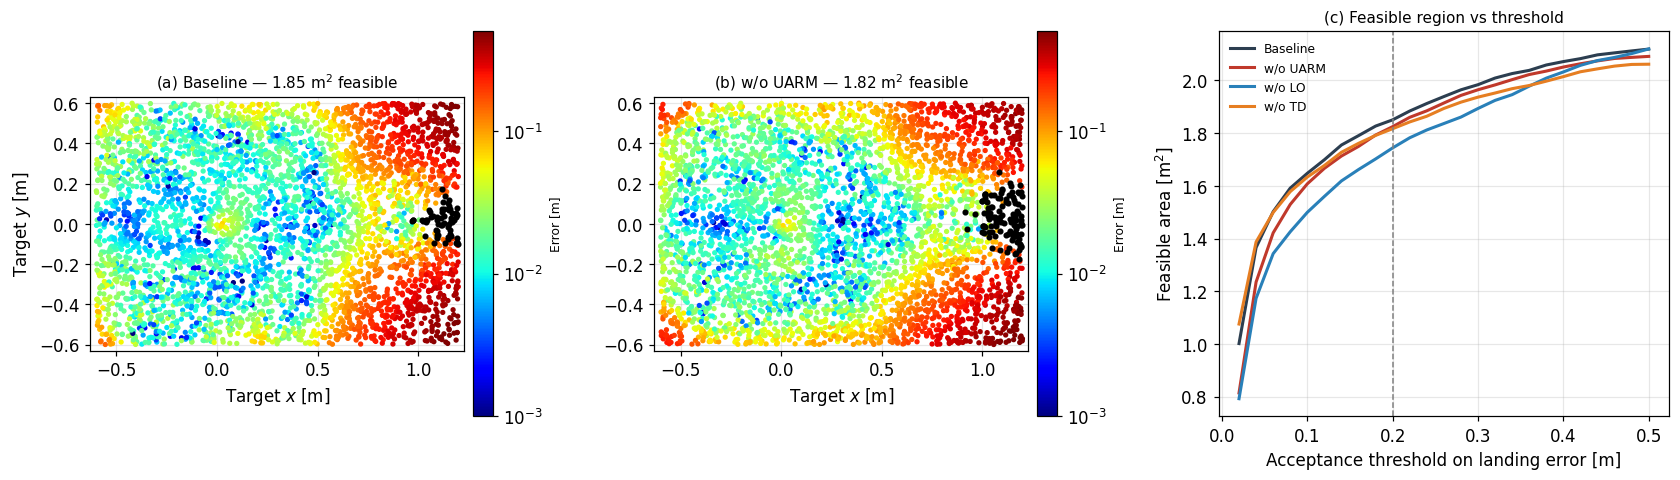

UARM gap vs distance: slope +0.0145 m/m (95% CI [-0.0041, +0.0331]), Spearman rho -0.01 (p 8.83e-01)
                     near cells +0.0039 m | far cells +0.0151 m


In [45]:
fig = plt.figure(figsize=(15.5, 4.5))
CX = part.centroids[:, 0].reshape(part.nx, part.ny)
CY = part.centroids[:, 1].reshape(part.nx, part.ny)
pair = [BASELINE] + [a for a in ["no_uarm"] if a in exps]

# (a)(b) paper-style scatter for baseline and w/o UARM
for i, n in enumerate(pair[:2]):
    ax = fig.add_subplot(1, 3, i + 1)
    e = exps[n]
    sc = ax.scatter(e.des_pos[e.ok, 0], e.des_pos[e.ok, 1], s=6, c=e.pos_err[e.ok],
                    norm=LogNorm(vmin=1e-3, vmax=0.5), cmap="jet", zorder=5)
    ax.scatter(e.des_pos[~e.ok, 0], e.des_pos[~e.ok, 1], s=9, color="black", zorder=10)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
    ax.set_title(f"({chr(97+i)}) {e.label} — {feas_area[n]:.2f} m$^2$ feasible", fontsize=10)
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
    cb = fig.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label("Error [m]", fontsize=8)
    cb.ax.minorticks_off()

# (c) area vs threshold
ax = fig.add_subplot(1, 3, 3)
thrs = np.linspace(0.02, 0.5, 25)
for n, e in exps.items():
    ax.plot(thrs, [effective_area(n, t) for t in thrs], lw=2, color=e.color, label=e.label)
ax.axvline(ERR_ACCEPT, color="grey", ls="--", lw=1)
ax.set_xlabel("Acceptance threshold on landing error [m]")
ax.set_ylabel("Feasible area [m$^2$]")
ax.set_title(f"(c) Feasible region vs threshold", fontsize=10)
ax.legend(fontsize=8)

fig.tight_layout()
savefig(fig, "fig_uarm_feasible_region")
plt.show()

if "no_uarm" in exps:
    d = (CELL["pos_err_pen"]["no_uarm"].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    r = cdist[valid_cells]
    m = np.isfinite(d)
    lr, rho = stats.linregress(r[m], d[m]), stats.spearmanr(r[m], d[m])
    near = r[m] < np.median(r[m])
    print(f"UARM gap vs distance: slope {lr.slope:+.4f} m/m "
          f"(95% CI [{lr.slope-1.96*lr.stderr:+.4f}, {lr.slope+1.96*lr.stderr:+.4f}]), "
          f"Spearman rho {rho.statistic:+.2f} (p {rho.pvalue:.2e})")
    print(f"                     near cells {d[m][near].mean():+.4f} m | "
          f"far cells {d[m][~near].mean():+.4f} m")

## 10. Supporting material

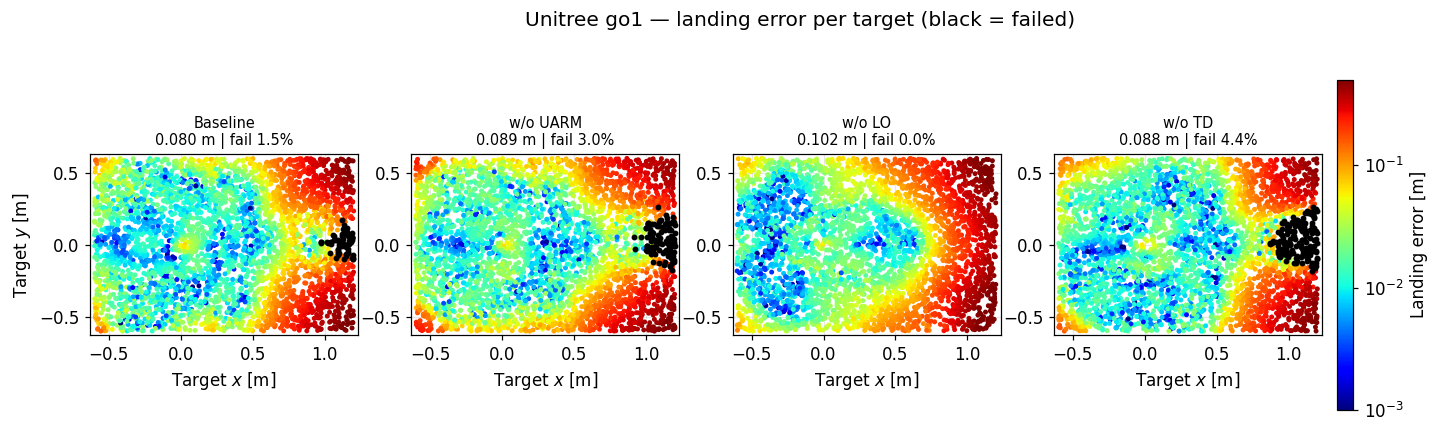

In [46]:
# per-policy absolute error maps, paper Fig. 10 style
fig, axes = plt.subplots(1, len(exps), figsize=(4.3 * len(exps), 3.9))
axes = np.atleast_1d(axes)
for ax, (n, e) in zip(axes, exps.items()):
    sc = ax.scatter(e.des_pos[e.ok, 0], e.des_pos[e.ok, 1], s=5, c=e.pos_err[e.ok],
                    norm=LogNorm(vmin=1e-3, vmax=0.5), cmap="jet", zorder=5)
    ax.scatter(e.des_pos[~e.ok, 0], e.des_pos[~e.ok, 1], s=8, color="black", zorder=10)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
    ax.set_title(f"{e.label}\n{strat('pos_err_pen', n):.3f} m | fail {strat('fail', n):.1f}%",
                 fontsize=9.5)
axes[0].set_ylabel("Target $y$ [m]")
cb = fig.colorbar(sc, ax=axes.tolist(), pad=0.01)
cb.set_label("Landing error [m]")
cb.ax.minorticks_off()
fig.suptitle(f"Unitree {robot} — landing error per target (black = failed)", y=1.04)
savefig(fig, "support_error_maps")
plt.show()

w/o LO: no failures in 4096 jumps -> report '<0.061% (95% upper bound)'


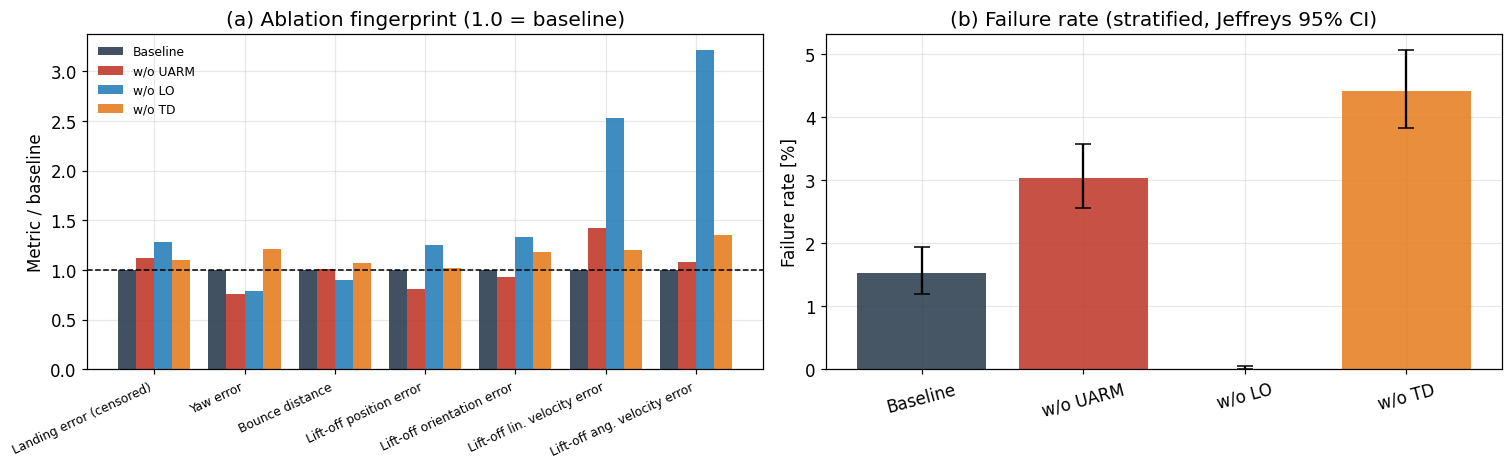

In [47]:
# ablation fingerprint + failure rates with Jeffreys intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

fp_attrs = [a for a in ("pos_err_pen", "yaw_err", "bounce", "lo_pos", "lo_orient",
                        "lo_vel", "lo_ang_vel")
            if np.isfinite(CELL[a][BASELINE].values[valid_cells]).any()]
ax = axes[0]
x = np.arange(len(fp_attrs)); w = 0.8 / max(len(exps), 1)
for i, (n, e) in enumerate(exps.items()):
    ax.bar(x + i * w - 0.4 + w / 2,
           [strat(a, n) / max(strat(a, BASELINE), 1e-12) for a in fp_attrs],
           width=w, color=e.color, alpha=0.9, label=e.label)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([MNAME[a] for a in fp_attrs], rotation=25, ha="right", fontsize=8)
ax.set_ylabel("Metric / baseline")
ax.set_title("(a) Ablation fingerprint (1.0 = baseline)")
ax.legend(fontsize=8)

ax = axes[1]
rates, elo, ehi = [], [], []
for n, e in exps.items():
    k, nn = int(e.fail.sum()), e.n
    p = k / nn
    lo, hi = stats.beta.ppf([0.025, 0.975], k + 0.5, nn - k + 0.5)
    if k == 0:
        lo = 0.0            # Jeffreys boundary convention
    if k == nn:
        hi = 1.0
    rates.append(strat("fail", n))
    elo.append(100 * max(p - lo, 0.0)); ehi.append(100 * max(hi - p, 0.0))
    if k == 0:
        print(f"{e.label}: no failures in {nn} jumps -> report '<{100*hi:.3f}% (95% upper bound)'")
ax.bar(LABELS, rates, yerr=[elo, ehi], color=CLR, alpha=0.88, capsize=5)
ax.set_ylabel("Failure rate [%]")
ax.set_title("(b) Failure rate (stratified, Jeffreys 95% CI)")
ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
savefig(fig, "support_fingerprint_failures")
plt.show()

In [48]:
# full paired-statistics table + LaTeX for the paper
stats_df.to_csv(osp.join(FIG_DIR, "ablation_cell_stats.csv"), index=False)

paper_tbl = pd.DataFrame([{
    "Policy": e.label,
    "Feas. area [m$^2$]": feas_area[n],
    "Landing err [m]": strat("pos_err_pen", n),
    "Failures [\\%]": strat("fail", n),
    "Bounce [m]": strat("bounce", n),
    "Invalid TD [\\%]": strat("invalid_td", n),
    "LO vel. err [m/s]": strat("lo_vel", n),
    "Pred. err [m]": strat(KEY, n),
} for n, e in exps.items()])
tex = paper_tbl.to_latex(index=False, float_format="%.3f", escape=False)
with open(osp.join(FIG_DIR, "ablation_table.tex"), "w") as fh:
    fh.write(tex)
print(tex)
stats_df[["Ablation", "Metric", "baseline", "ablation", "diff", "ci_lo", "ci_hi", "rel",
          "worse", "p_holm", "sig"]].round(4)

\begin{tabular}{lrrrrrrr}
\toprule
Policy & Feas. area [m$^2$] & Landing err [m] & Failures [\%] & Bounce [m] & Invalid TD [\%] & LO vel. err [m/s] & Pred. err [m] \\
\midrule
Baseline & 1.850 & 0.080 & 1.534 & 0.158 & 0.000 & 0.198 & 0.110 \\
w/o UARM & 1.824 & 0.089 & 3.029 & 0.160 & 0.000 & 0.281 & 0.144 \\
w/o LO & 1.744 & 0.102 & 0.000 & 0.142 & 0.000 & 0.501 & 0.252 \\
w/o TD & 1.817 & 0.088 & 4.411 & 0.169 & 0.000 & 0.238 & 0.129 \\
\bottomrule
\end{tabular}



,Ablation,Metric,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
0,w/o UARM,Landing error (censored) [m],0.0796,0.0892,0.0095,0.0044,0.0153,11.9432,65.3333,0.0047,**
1,w/o UARM,Landing error | success [m],0.0734,0.0773,0.0038,0.0004,0.0074,5.2230,61.0738,0.2408,n.s.
2,w/o UARM,Landing error (all jumps) [m],0.0740,0.0781,0.0041,0.0008,0.0077,5.5847,63.3333,0.1169,n.s.
3,w/o UARM,Failure rate [%],1.5343,3.0294,1.4951,0.4160,2.8750,97.4444,6.0000,0.1169,n.s.
4,w/o UARM,Invalid touchdown rate [%],0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,1.0000,n.s.
5,w/o UARM,Acceptable @ 0.2 m [%],85.6749,84.4802,-1.1947,-2.8871,0.3674,-1.3945,8.0000,1.0000,n.s.
6,w/o UARM,Acceptable @ 0.1 m [%],76.2817,74.4326,-1.8491,-4.1952,0.3022,-2.4240,7.3333,0.5605,n.s.
7,w/o UARM,Yaw error [deg],3.7175,2.8169,-0.9006,-1.3885,-0.4539,-24.2262,44.2953,0.0598,n.s.
8,w/o UARM,Bounce distance [m],0.1579,0.1598,0.0019,-0.0014,0.0054,1.2349,57.0470,1.0000,n.s.
9,w/o UARM,Lift-off position error [m],0.0209,0.0170,-0.0040,-0.0046,-0.0034,-18.9550,16.1074,0.0000,***


## 11. Draft text for Section 5.6

In [49]:
def fp(p):
    return "< 0.001" if p < 1e-3 else f"= {p:.3f}"


L = ["# Section 5.6 — Ablation study (auto-generated draft)", ""]
L.append(f"Each policy was evaluated on an independently sampled random target set "
         f"({', '.join(f'{e.label}: {e.n}' for e in exps.values())} jumps). Since the target sets "
         f"differ, policies are compared over a shared {GRID_NX}x{GRID_NY} partition of the command "
         f"space ({int(VALID.sum())} usable cells, {TOTAL_AREA:.2f} m2); reported values are "
         f"stratified over cells, confidence intervals are cluster bootstraps over cells, and "
         f"p-values are Wilcoxon signed-rank over cells with Holm correction. Landing error is "
         f"censored at {PEN_CAP} m for failed jumps so that a failure-prone policy cannot look "
         f"accurate through survivorship.")
L.append("")
L.append(as_markdown(paper_tbl))
L.append("")

if "no_uarm" in exps:
    b, a = feas_area[BASELINE], feas_area["no_uarm"]
    d = (CELL["pos_err_pen"]["no_uarm"].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    r = cdist[valid_cells]
    m = np.isfinite(d)
    rho = stats.spearmanr(r[m], d[m])
    near = r[m] < np.median(r[m])
    L.append("## UARM extension")
    L.append("")
    L.append(f"Removing the UARM segment reduces the feasible region (landing error below "
             f"{ERR_ACCEPT} m) from **{b:.3f} m2 to {a:.3f} m2** ({100*(a-b)/b:+.1f}%) and the "
             f"usable range from {feas_df.loc[exps[BASELINE].label,'Usable range [m]']:.2f} m to "
             f"{feas_df.loc[exps['no_uarm'].label,'Usable range [m]']:.2f} m. The landing error "
             f"grows from {strat('pos_err_pen', BASELINE):.3f} m to "
             f"{strat('pos_err_pen','no_uarm'):.3f} m ({S('no_uarm','pos_err_pen','rel'):+.0f}%, "
             f"95% CI [{S('no_uarm','pos_err_pen','ci_lo'):+.3f}, "
             f"{S('no_uarm','pos_err_pen','ci_hi'):+.3f}] m, p "
             f"{fp(S('no_uarm','pos_err_pen','p_holm'))}), and the failure rate from "
             f"{strat('fail', BASELINE):.2f}% to {strat('fail','no_uarm'):.2f}%.")
    L.append(f"The degradation is concentrated at long range ({d[m][near].mean():+.3f} m on near "
             f"cells vs {d[m][~near].mean():+.3f} m on far cells, Spearman rho "
             f"{rho.statistic:+.2f}, p {fp(rho.pvalue)}), consistent with the pure-Bezier "
             f"trajectory being unable to charge for long jumps without violating the "
             f"minimum-height constraint (Fig. 6).")
    L.append("")

if "no_liftoof_disc_penalty" in exps:
    n = "no_liftoof_disc_penalty"
    parts = [f"{MNAME[a].replace('Lift-off ','').replace(' error','')} "
             f"{S(n,a,'rel'):+.0f}%" for a in LO_ATTRS if np.isfinite(S(n, a, "rel"))]
    L.append("## Lift-off state penalty")
    L.append("")
    L.append(f"Removing the lift-off penalty degrades tracking of the commanded lift-off state "
             f"({'; '.join(parts)}).")
    if BALLISTIC:
        L.append(f"As a consequence the physical interpretation of Section 5.2 can no longer be "
                 f"applied: the ballistic equations are evaluated on the commanded lift-off state "
                 f"before the jump is executed, and the distance between the landing point they "
                 f"predict and the one actually reached grows from "
                 f"{strat('pred_err_filter', BASELINE):.3f} m to "
                 f"{strat('pred_err_filter', n):.3f} m ({S(n,'pred_err_filter','rel'):+.0f}%, "
                 f"p {fp(S(n,'pred_err_filter','p_holm'))}). Decomposing this error, the "
                 f"contribution of lift-off tracking rises from {strat('pred_err_lo', BASELINE):.3f} m "
                 f"to {strat('pred_err_lo', n):.3f} m while the ballistic model contribution is "
                 f"unchanged ({strat('pred_err_model', BASELINE):.3f} m vs "
                 f"{strat('pred_err_model', n):.3f} m), showing that the loss of predictability "
                 f"originates in the lift-off state and not in the flight model. The apex "
                 f"predicted by (27) departs from the achieved one by "
                 f"{strat('apex_err', n):.3f} m against {strat('apex_err', BASELINE):.3f} m for "
                 f"the baseline, so the pre-jump feasibility check is no longer reliable.")
    else:
        L.append(f"Propagating these errors through the flight phase to first order bounds the "
                 f"induced landing-prediction error at {strat('pred_err_lo', BASELINE):.3f} m for "
                 f"the baseline against {strat('pred_err_lo', n):.3f} m without the penalty "
                 f"({S(n,'pred_err_lo','rel'):+.0f}%). [Log the commanded and achieved lift-off "
                 f"states as pairs to replace this bound with the exact prediction error.]")
    L.append("")

n = "no_bounce_angular_touchdown"
if n in exps and exps[n].bounce is not None:
    L.append("## Touchdown bounce and angular-velocity penalties")
    L.append("")
    L.append(f"Removing the touchdown penalties increases the bounce — the displacement between "
             f"the first detected touchdown and the resting position — from "
             f"{strat('bounce', BASELINE):.3f} m to {strat('bounce', n):.3f} m "
             f"({S(n,'bounce','rel'):+.0f}%, 95% CI [{S(n,'bounce','ci_lo'):+.3f}, "
             f"{S(n,'bounce','ci_hi'):+.3f}] m, p {fp(S(n,'bounce','p_holm'))}), with a larger "
             f"bounce in {S(n,'bounce','worse'):.0f}% of the workspace. The rate of invalid "
             f"touchdowns rises from {strat('invalid_td', BASELINE):.2f}% to "
             f"{strat('invalid_td', n):.2f}% and the failure rate from "
             f"{strat('fail', BASELINE):.2f}% to {strat('fail', n):.2f}%. Since no landing "
             f"controller is used, this residual horizontal kinetic energy cannot be dissipated, "
             f"so these are precisely the landing conditions the penalty is meant to avoid.")
    db = (CELL["bounce"][n].values - CELL["bounce"][BASELINE].values)[valid_cells]
    de = (CELL["pos_err_pen"][n].values - CELL["pos_err_pen"][BASELINE].values)[valid_cells]
    mm = np.isfinite(db) & np.isfinite(de)
    rr = stats.pearsonr(db[mm], de[mm])
    if rr.pvalue < 0.05:
        L.append(f"Across the workspace the increase in bounce correlates with the increase in "
                 f"landing error (r = {rr.statistic:.2f}, p {fp(rr.pvalue)}), indicating that the "
                 f"rebounces also cost landing accuracy.")
    else:
        L.append(f"The per-cell increase in bounce is not significantly correlated with the "
                 f"increase in landing error (r = {rr.statistic:.2f}, p {fp(rr.pvalue)}), so the "
                 f"effect of this penalty is on landing stability rather than on accuracy.")
    L.append("")

L.append("## Caveats to keep")
L.append("")
L.append("- Single training seed per condition: the p-values quantify variation across the command "
         "space, not across training runs.")
L.append("- No landing controller is used, so all landing figures are a lower bound on achievable "
         "performance (consistent with Section 5.3.1).")

report = "\n".join(L)
with open(osp.join(FIG_DIR, "section_5_6_draft.md"), "w") as fh:
    fh.write(report)
print(report)

# Section 5.6 — Ablation study (auto-generated draft)

Each policy was evaluated on an independently sampled random target set (Baseline: 4096, w/o UARM: 4096, w/o LO: 4096, w/o TD: 4096 jumps). Since the target sets differ, policies are compared over a shared 15x10 partition of the command space (150 usable cells, 2.16 m2); reported values are stratified over cells, confidence intervals are cluster bootstraps over cells, and p-values are Wilcoxon signed-rank over cells with Holm correction. Landing error is censored at 0.5 m for failed jumps so that a failure-prone policy cannot look accurate through survivorship.

  Policy  Feas. area [m$^2$]  Landing err [m]  Failures [\%]  Bounce [m]  Invalid TD [\%]  LO vel. err [m/s]  Pred. err [m]
Baseline            1.850210         0.079646       1.534306    0.157898              0.0           0.198112       0.110088
w/o UARM            1.824410         0.089158       3.029401    0.159848              0.0           0.281384       0.143592
  w/

In [50]:
print("outputs in:", FIG_DIR)
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)

outputs in: /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation/figures_ablation
   ablation_cell_stats.csv
   ablation_fingerprint.pdf
   ablation_fingerprint.png
   ablation_headline.tex
   ablation_paired_stats.csv
   ablation_paper_figure.pdf
   ablation_paper_figure.png
   ablation_primary_stats.tex
   ablation_report.md
   ablation_summary.csv
   ablation_summary.tex
   ablation_table.tex
   bounce_analysis.pdf
   bounce_analysis.png
   bounce_mechanism.pdf
   bounce_mechanism.png
   cellmap_delta_error.pdf
   cellmap_delta_error.png
   cellmap_delta_failure.pdf
   cellmap_delta_failure.png
   cellmap_error.pdf
   cellmap_error.png
   claim1_area_vs_threshold.pdf
   claim1_area_vs_threshold.png
   claim1_uarm_feasible_region.pdf
   claim1_uarm_feasible_region.png
   claim1_uarm_vs_distance.pdf
   claim1_uarm_vs_distance.png
   claim2_liftoff_predictability.pdf
   claim2_liftoff_predictability.png
   claim3_bounce_mechanism.pdf
   claim3_bounce_mechanism.